# Exparimentation with season functionality

In [1]:
import os

PROJECT_ROOT = "/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model"
os.chdir(PROJECT_ROOT)

%pwd



# Enable auto-reloading of custom modules
%load_ext autoreload
%autoreload 2

In [2]:
from season.persons import SeasonPerson
from season.configs import ScheduleSpecs, SeasonConfig, DayParams, make_season_config, PopulationParams
from season.season_orchestrator import SeasonOrchestrator

import numpy as np
import pandas as pd
from scipy.stats import norm, lognorm, skewnorm, truncnorm, uniform


# Creating Schedules for TM 

In [ ]:


# Example ScheduleSpecs
# traffic_percentile_schedule = ScheduleSpecs(
#     mode='dist',
#     value=None,
#     dist=uniform(loc=60, scale=40),  # uniform distribution between 60 and 80
#     round_to_int=True
# )

traffic_percentile_schedule = ScheduleSpecs(
    mode='static',
    value=75
)

bus_interval_schedule = ScheduleSpecs(
    mode='static',
    value=30,  # static bus interval of 15 minutes
    dist=None
)

crashes_schedule = ScheduleSpecs(
    mode='static',
    value=0,
    #dist=norm(loc=5, scale=1)  # normal distribution for crashes per 100k VMT
)



In [15]:
traffic_percentile_schedule = ScheduleSpecs(
     mode='static',
    value=83,  
    dist=None
)

bus_interval_schedule = ScheduleSpecs(
    mode='static',
    value=30,  # static bus interval of 15 minutes
    dist=None
)

crashes_schedule = ScheduleSpecs(
    mode='static',
    value=4,  # static bus interval of 15 minutes
    dist=None # normal distribution for crashes per 100k VMT
)


print(traffic_percentile_schedule.realize( n_days=15))
print(crashes_schedule.realize( n_days=15))

[83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83]
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


# Defining the Population Perams

In [16]:
pop_params = PopulationParams(
    population_size=2000,
    value_of_time=lognorm(s=0.64, scale=40/60),
    experience_weight_car=1.0,
    experience_weight_bus=skewnorm(6, loc=1.15, scale=0.3),
    prior_car=22.0,
    prior_bus=40.0,
    time_decay_rate=0.1,
    prior_weight=1.0,
    uncertainty_multiplier=1.0,
    travel_propensity=1.0,
)

pop_params.create_season_persons(
    season_id="test_season",
    seed=42,
)

example_config = make_season_config(
    season_id='two_week_example_001',
    run_description='Example config with custom schedules',
    seed=123,
    n_days=14,
    max_steps=10000,
    max_persons=2000,
    collect_every_n=1000,
    start_hr=8,
    bus_capacity=30,
    road_path='data/roads/hw210_sl_and_curvs.parquet',
    ecs_path='data/vehicle_counts/expected_counts_seconds.csv',
    toll_mechanism='static',
    toll_params={'car': 8.0, 'bus': 0.0},
    canyon_closures_schedule=None,
    traffic_percentile_schedule=traffic_percentile_schedule,
    bus_interval_schedule=bus_interval_schedule,
    crashes_schedule=crashes_schedule, 
    population_params=pop_params
   
)

light_config = make_season_config(
    season_id='light_season_001',
    run_description='Light config for testing',
    seed=123,
    n_days=15,
    max_steps=3000,
    max_persons=500,
    collect_every_n=10,
    road_path='data/roads/hw210_sl_and_curvs.parquet',
    ecs_path='data/vehicle_counts/expected_counts_seconds.csv',
    toll_mechanism='static',
    toll_params={'car': 8.0, 'bus': 0.0},
    population_params=pop_params,
    crashes_schedule=crashes_schedule
    
)

In [7]:
light_config

SeasonConfig(season_id='light_season_001', run_description='Light config for testing', seed=123, n_days=15, max_steps=3000, max_persons=500, collect_every_n=10, start_hr=5, bus_capacity=30, road_path='data/roads/hw210_sl_and_curvs.parquet', ecs_path='data/vehicle_counts/expected_counts_seconds.csv', toll_mechanism='static', toll_params={'car': 8.0, 'bus': 0.0}, day_params=[DayParams(day_index=0, day_seed=123, traffic_percentile=50, bus_interval=30, crashes_per_100k_vmt_input=77.0, canyon_closures=None), DayParams(day_index=1, day_seed=124, traffic_percentile=50, bus_interval=30, crashes_per_100k_vmt_input=79.0, canyon_closures=None), DayParams(day_index=2, day_seed=125, traffic_percentile=50, bus_interval=30, crashes_per_100k_vmt_input=84.0, canyon_closures=None), DayParams(day_index=3, day_seed=126, traffic_percentile=50, bus_interval=30, crashes_per_100k_vmt_input=81.0, canyon_closures=None), DayParams(day_index=4, day_seed=127, traffic_percentile=50, bus_interval=30, crashes_per_100

Season outputs will be saved to: data/season_outputs/two_week_example_001
Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   3%|▎         | 326/10000 [00:00<00:20, 479.45step/s]

crash at step 265


Simulating: 100%|██████████| 10000/10000 [01:14<00:00, 134.89step/s]

Reached max step count (10000). Stopping model.
Number of bus riders 142 vs car riders 1858
N cars: 1538, fake hours: 2.8


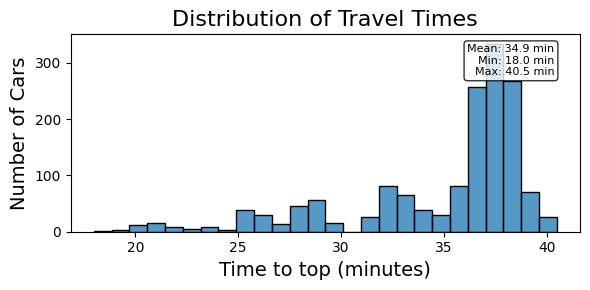

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   6%|▌         | 621/10000 [00:02<00:34, 274.76step/s]

crash at step 573


Simulating: 100%|██████████| 10000/10000 [01:10<00:00, 142.15step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 164 vs car riders 1836
N cars: 1521, fake hours: 2.8


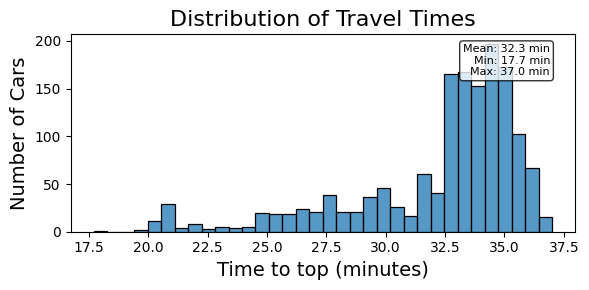

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   4%|▍         | 426/10000 [00:00<00:21, 448.32step/s]

crash at step 358


Simulating: 100%|██████████| 10000/10000 [01:12<00:00, 138.01step/s]

Reached max step count (10000). Stopping model.
Number of bus riders 161 vs car riders 1839
N cars: 1517, fake hours: 2.8


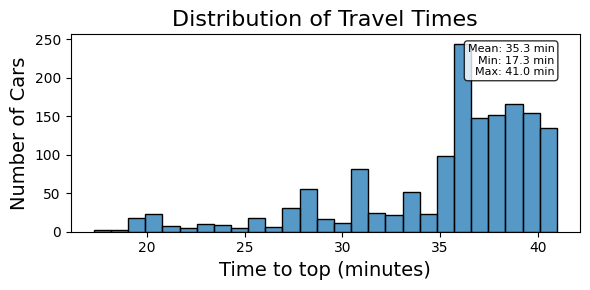

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   3%|▎         | 333/10000 [00:00<00:22, 421.15step/s]

crash at step 270


Simulating: 100%|██████████| 10000/10000 [01:11<00:00, 140.63step/s]

Reached max step count (10000). Stopping model.
Number of bus riders 146 vs car riders 1854
N cars: 1573, fake hours: 2.8


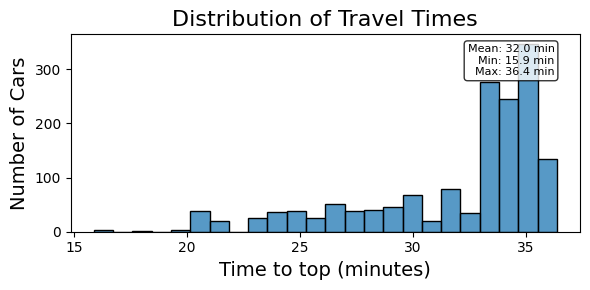

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   3%|▎         | 294/10000 [00:00<00:19, 504.51step/s]

crash at step 261


Simulating: 100%|██████████| 10000/10000 [01:19<00:00, 126.07step/s]

Reached max step count (10000). Stopping model.
Number of bus riders 140 vs car riders 1860
N cars: 1536, fake hours: 2.8


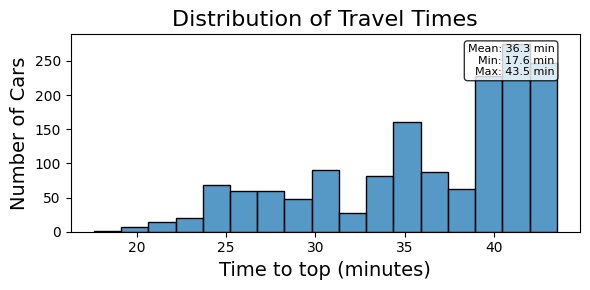

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   2%|▏         | 242/10000 [00:00<00:16, 593.16step/s]

crash at step 228


Simulating: 100%|██████████| 10000/10000 [01:10<00:00, 140.88step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 125 vs car riders 1875
N cars: 1528, fake hours: 2.8


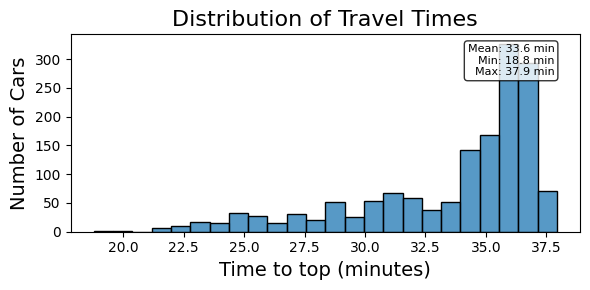

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   4%|▍         | 397/10000 [00:00<00:21, 436.82step/s]

crash at step 310


Simulating: 100%|██████████| 10000/10000 [01:14<00:00, 134.44step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 124 vs car riders 1876
N cars: 1518, fake hours: 2.8


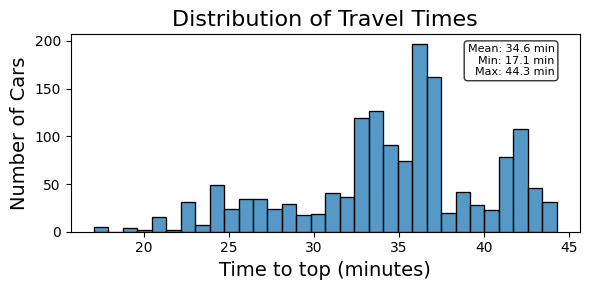

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   4%|▍         | 401/10000 [00:00<00:25, 383.31step/s]

crash at step 350


Simulating: 100%|██████████| 10000/10000 [01:16<00:00, 130.25step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 129 vs car riders 1871
N cars: 1521, fake hours: 2.8


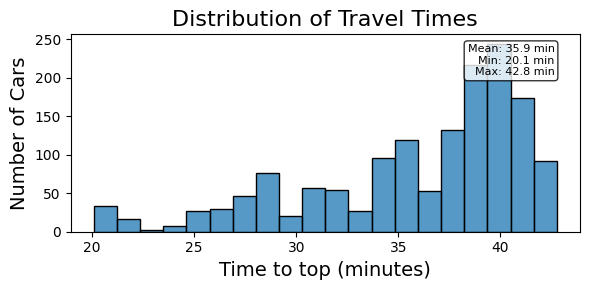

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   5%|▍         | 462/10000 [00:01<00:30, 314.80step/s]

crash at step 437


Simulating: 100%|██████████| 10000/10000 [01:12<00:00, 137.53step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 156 vs car riders 1844
N cars: 1492, fake hours: 2.8


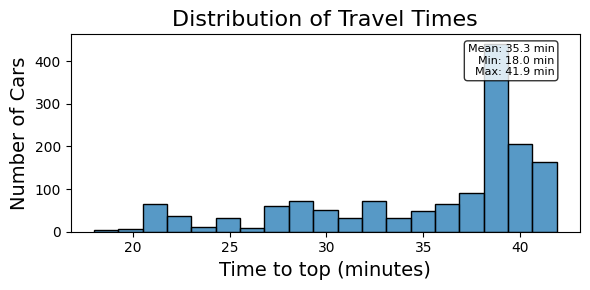

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   3%|▎         | 318/10000 [00:00<00:18, 520.87step/s]

crash at step 272


Simulating: 100%|██████████| 10000/10000 [01:09<00:00, 144.08step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 159 vs car riders 1841
N cars: 1539, fake hours: 2.8


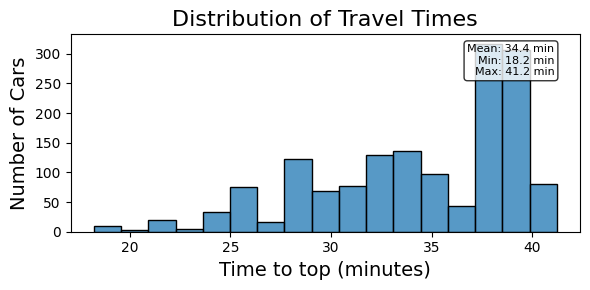

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   3%|▎         | 307/10000 [00:00<00:17, 544.41step/s]

crash at step 195


Simulating: 100%|██████████| 10000/10000 [01:10<00:00, 141.63step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 119 vs car riders 1881
N cars: 1474, fake hours: 2.8


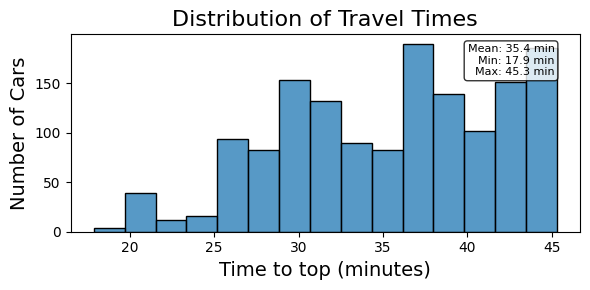

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   6%|▌         | 603/10000 [00:01<00:30, 310.84step/s]

crash at step 569


Simulating: 100%|██████████| 10000/10000 [01:11<00:00, 139.84step/s]

Reached max step count (10000). Stopping model.
Number of bus riders 151 vs car riders 1849
N cars: 1548, fake hours: 2.8


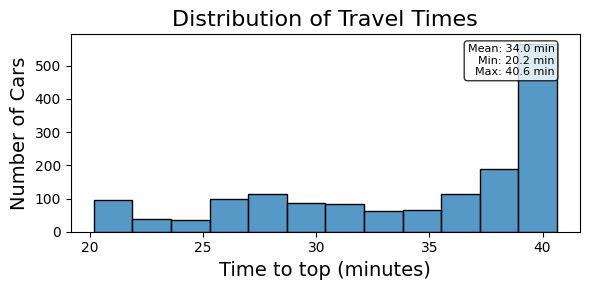

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   4%|▎         | 351/10000 [00:00<00:20, 468.32step/s]

crash at step 313


Simulating: 100%|██████████| 10000/10000 [01:07<00:00, 147.55step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 135 vs car riders 1865
N cars: 1531, fake hours: 2.8


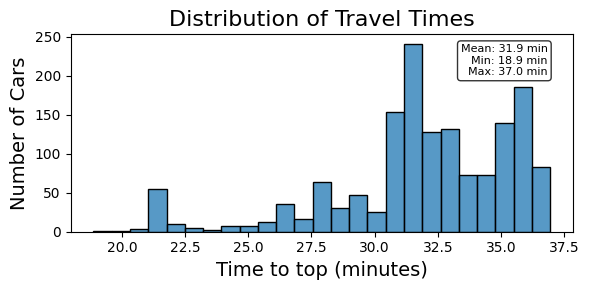

Toll mechanism: static with params {'car': 8.0, 'bus': 0.0}


Simulating:   5%|▌         | 504/10000 [00:01<00:30, 307.65step/s]

crash at step 468


Simulating: 100%|██████████| 10000/10000 [01:08<00:00, 145.99step/s]


Reached max step count (10000). Stopping model.
Number of bus riders 122 vs car riders 1878
N cars: 1517, fake hours: 2.8


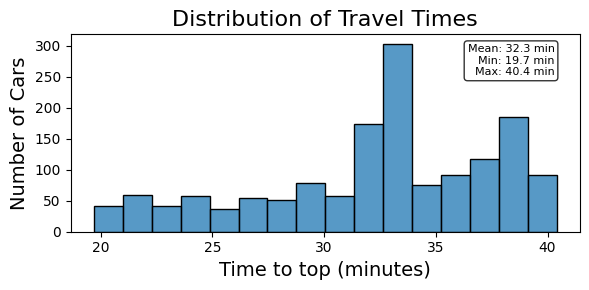

In [17]:
# Example usage of SeasonOrchestrator with example_config
orchestrator = SeasonOrchestrator(season_config=example_config, output_dir="data/season_outputs")
orchestrator.run_season()



In [ ]:
pd.read_parquet("/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model/data/season_outputs/example_season_001/day_1_model_ts.parquet")

In [ ]:
travel_data = [(10, 5.2), (20, 6.3), (30, 5.8)]

days, tts = zip(*travel_data)